## DPFSPDD using CONSTRAINT PROGRAMMING 

---

1. Load Problem's Data 
2. Model and Solve
3. Display the solution, graphically

In [170]:
# Load Problem's Data
import os

# filepath = "datasets/small/I_2_4_2_1.txt" # 27_ο=
filepath = "datasets/small/I_3_12_5_4.txt"  # 633_o+
# filepath = "datasets/large/Ta003_4.txt"

ptime = {}
jobs_due_date = {}
problem_Category = os.path.basename(os.path.dirname(filepath))
problem_id = os.path.splitext(os.path.basename(filepath))[0]
with open(filepath, encoding="utf-8") as f:
    line1 = f.readline().strip().split()
    J, M = int(line1[0]), int(line1[1])
    line2 = f.readline().strip()
    F = int(line2)
    for j in range(J):
        line = f.readline().strip().split()
        ptime[j] = []
        for m in range(M):
            ptime[j].append(int(line[2 * m + 1]))
    line3 = f.readline().strip()
    assert line3 == "Duedate"
    for j in range(J):
        jobs_due_date[j] = int(f.readline().strip())


# display the problem
for k, v in ptime.items():
    print(f"{k:3d}", end=": ")
    for x in v:
        print(f"{x:3d}", end="")
    print(f"| {jobs_due_date[k]:4d}")
print(f"problem={problem_id}, factories={F}, jobs={J}, machines={M}")

  0:  52 35 49 54 19|  214
  1:  76 16 58 75 42|  270
  2:  99  3 38 47 43|  237
  3:  96 19 80  6 81|  282
  4:  80 95  5 80 16|  284
  5:  17 46 35 77 12|  191
  6:  97 44 18 19 73|  256
  7:  40 17 91 10 65|  228
  8:   4 32 71 31 95|  239
  9:  15  3 73 25  9|  125
 10:  13 42  9 76 77|  223
 11:  71 88 88 77 48|  372
problem=I_3_12_5_4, factories=3, jobs=12, machines=5


In [171]:
from ortools.sat.python import cp_model
from itertools import combinations
from collections import defaultdict
import pandas as pd

JOBS = range(J)
MACHINES = range(M)
FACTORIES = range(F)

# Large upper bound for times
UB = sum(ptime[j][m] for j in JOBS for m in MACHINES) + 100
print("LARGER UPPER BOUND:", UB)

model = cp_model.CpModel()

# VARIABLES
x = defaultdict(cp_model.IntVar)  # interval variables for each job, factory, machine
b = defaultdict(
    cp_model.IntVar
)  # boolean variables for each job, factory `b[j, f] = 1` if job j is assigned to factory f
start = defaultdict(cp_model.IntVar)  # start time of job j on machine m
end = defaultdict(cp_model.IntVar)  # end time of job j on machine m
t = defaultdict(
    cp_model.IntVar
)  # integer variables measuring the tardiness of each job
# assignment b[j,f] : job j assigned to factory f
b = {(j, f): model.NewBoolVar(f"b_{j}_{f}") for j in JOBS for f in FACTORIES}
y ={f: model.NewIntVar(0, J, f"y_{f}") for f in FACTORIES}

# interval variables: for each job j, factory f, machine m:
# create start_j_f_m (IntVar), end_j_f_m (IntVar) and optional interval x_j_f_m
for j in JOBS:
    t[j] = model.new_int_var(0, UB, name=f"t_{j}")
    for f in FACTORIES:
        for m in MACHINES:
            s = model.NewIntVar(0, UB, f"start_{j}_{f}_{m}")
            e = model.NewIntVar(0, UB, f"end_{j}_{f}_{m}")
            p = ptime[j][m]
            x[j, f, m] = model.NewOptionalIntervalVar(
                s, p, e, b[j, f], f"x_{j}_{f}_{m}"
            )
            start[j, f, m] = s
            end[j, f, m] = e

# order variables o[j1,j2,f]
o = {}
for j1, j2 in combinations(JOBS, 2):
    for f in FACTORIES:
        o[j1, j2, f] = model.NewBoolVar(
            f"o_{j1}_{j2}_{f}"
        )  # oj1,j2,f​=1 -> end(xj1,f,m​) <= start(xj2,f,m​)
        o[j2, j1, f] = model.NewBoolVar(
            f"o_{j2}_{j1}_{f}"
        )  # oj2,j1,f​=1 -> end(xj2,f,m​) <= start(xj1,f,m​)​

# CONSTRAINTS
# MODEL EQUATION (2) -  Each job assigned to exactly one factory
for j in JOBS:
    model.Add(sum(b[j, f] for f in FACTORIES) == 1)

# MODEL EQUATION (3) - No-overlap at first machine for each factory (global no-overlap)
for f in FACTORIES:
    model.AddNoOverlap([x[j, f, 0] for j in JOBS])

# MODEL EQUATION (4) order between pairs of jobs if they are in same factory
# Use o variables to impose a consistent order across all machines
for j1, j2 in combinations(JOBS, 2):
    for f in FACTORIES:
        # If both present and o[j1,j2,f]==1 => j1 before j2 on machine 0 (and we will propagate to all machines)
        model.Add(end[j1, f, 0] <= start[j2, f, 0]).OnlyEnforceIf(
            [o[j1, j2, f], b[j1, f], b[j2, f]]
        )
        model.Add(end[j2, f, 0] <= start[j1, f, 0]).OnlyEnforceIf(
            [o[j2, j1, f], b[j1, f], b[j2, f]]
        )
        # If either job not present then ordering variable is irrelevant:
        model.AddBoolOr([o[j1, j2, f], o[j2, j1, f], b[j1, f].Not(), b[j2, f].Not()])
for f in FACTORIES:
    for m in range(1, M):
        for j1, j2 in combinations(JOBS, 2):
            model.Add(end[j1, f, m] <= start[j2, f, m]).OnlyEnforceIf(
                [o[j1, j2, f], b[j1, f], b[j2, f]]
            )
            model.Add(end[j2, f, m] <= start[j1, f, m]).OnlyEnforceIf(
                [o[j2, j1, f], b[j1, f], b[j2, f]]
            )

# MODEL EQUATION (5) for each job in each factory, machine m starts after previous end
for j in JOBS:
    for f in FACTORIES:
        for m in range(1, M):
            model.Add(end[j, f, m - 1] <= start[j, f, m]).OnlyEnforceIf(b[j, f])

# MODEL EQUATION (6) tardiness definition
for j in JOBS:
    Dj = jobs_due_date[j]
    for f in FACTORIES:
        model.Add(t[j] >= end[j, f, M - 1] - Dj).OnlyEnforceIf(b[j, f])

# Symmetry breaking (7): b_0,0 = 1 (first job assigned to first factory)
model.Add(b[0, 0] == 1)
    
# if use_min_index_symmetry and y is not None and F > 2:
#y[f] <= j for every job j present at factory f (so y[f] becomes min index)
if F>2:
    for f in range(1, F):
        for j in JOBS:
            # if b[j,f] then y[f] <= j
            model.Add(y[f] <= j).OnlyEnforceIf(b[j, f])
    # enforce increasing y[f]
    for f in range(1, F - 1):
        model.Add(y[f] < y[f + 1])

# OBJECTIVE: minimize total tardiness Equation (1)
obj = model.NewIntVar(0, UB * J, "obj")
model.Add(obj == sum(t[j] for j in JOBS))
model.Minimize(obj)

print(model.model_stats())

LARGER UPPER BOUND: 2972
optimization model '': (model_fingerprint: 0x58a3854d7cc7baab)
#Variables: 808 (#ints: 1 in objective) (794 primary variables)
  - 432 Booleans in [0,1]
  - 3 in [0,12]
  - 372 in [0,2972]
  - 1 in [0,35664]
#kBoolOr: 198 (#literals: 792)
#kInterval: 180 (#enforced: 180)
#kLinear1: 25 (#enforced: 24)
#kLinear2: 2'161 (#enforced: 2'160 #multi: 1'980)
#kLinear3: 12
#kLinearN: 1 (#terms: 13)
#kNoOverlap: 3 (#intervals: 36, #optional: 36)


In [172]:
# SOLVE
solver = cp_model.CpSolver()
solver.parameters.max_time_in_seconds = 30
# solver.parameters.num_search_workers = 6
solver.parameters.log_search_progress = True
    
status = solver.Solve(model)
if status not in (cp_model.OPTIMAL, cp_model.FEASIBLE):
    raise RuntimeError("No solution found")

schedule = { (j,f,m): None for j in JOBS for f in FACTORIES for m in MACHINES }
assignment = { j: None for j in JOBS }
for j in JOBS:
    for f in FACTORIES:
        if solver.Value(b[j, f]) == 1:
            assignment[j] = f
            for m in MACHINES:
                schedule[j, f, m] = solver.Value(start[j, f, m])
                # DEL sol.schedule(j, f, m, solver.value(start[j, f, m]))
result = {
    "status": "OPTIMAL" if status == cp_model.OPTIMAL else "FEASIBLE",
    "objective": solver.ObjectiveValue(),
    "assignment": assignment,
    "start_times": schedule,
    "tardiness": { j: solver.Value(t[j]) for j in JOBS },
    "best_bound": solver.BestObjectiveBound(),
}
print("Objective value:", solver.objective_value)
print("Objective Best Bound:", solver.best_objective_bound)

              
summary = {
    "Solver Status": result["status"],
    "Objective (Total Tardiness)": result["objective"],
    "Best Bound": result["best_bound"],
    "Optimality Gap (%)": round(100 * (result["objective"] - result["best_bound"]) / result["objective"], 2)
    }
       
jobs_df = pd.DataFrame([
    {
    "Job": j,
    "Assigned Factory": result["assignment"][j],
    "Tardiness": result["tardiness"][j]
    }
    for j in result["assignment"]
    ])

FACTORIES = sorted({f for (_, f, _) in result["start_times"].keys()})
       
print(pd.DataFrame([summary]))                              #print SUMMARY
print(jobs_df)                                              #print jobs Assignments


Starting CP-SAT solver v9.15.6755
Parameters: max_time_in_seconds: 30 log_search_progress: true
Setting number of workers to 10

Initial optimization model '': (model_fingerprint: 0x58a3854d7cc7baab)
#Variables: 808 (#ints: 1 in objective) (794 primary variables)
  - 432 Booleans in [0,1]
  - 3 in [0,12]
  - 372 in [0,2972]
  - 1 in [0,35664]
#kBoolOr: 198 (#literals: 792)
#kInterval: 180 (#enforced: 180)
#kLinear1: 25 (#enforced: 24)
#kLinear2: 2'161 (#enforced: 2'160 #multi: 1'980)
#kLinear3: 12
#kLinearN: 1 (#terms: 13)
#kNoOverlap: 3 (#intervals: 36, #optional: 36)

Starting presolve at 0.01s
  8.98e-04s  0.00e+00d  [DetectDominanceRelations] 
  1.02e-02s  0.00e+00d  [PresolveToFixPoint] #num_loops=7 #num_dual_strengthening=2 
  2.00e-04s  0.00e+00d  [ExtractEncodingFromLinear] #potential_supersets=12 
  9.40e-04s  0.00e+00d  [DetectDuplicateColumns] 
  6.89e-04s  0.00e+00d  [DetectDuplicateConstraints] 
[Symmetry] Graph for symmetry has 3'631 nodes and 11'180 arcs.
[Symmetry] Sym

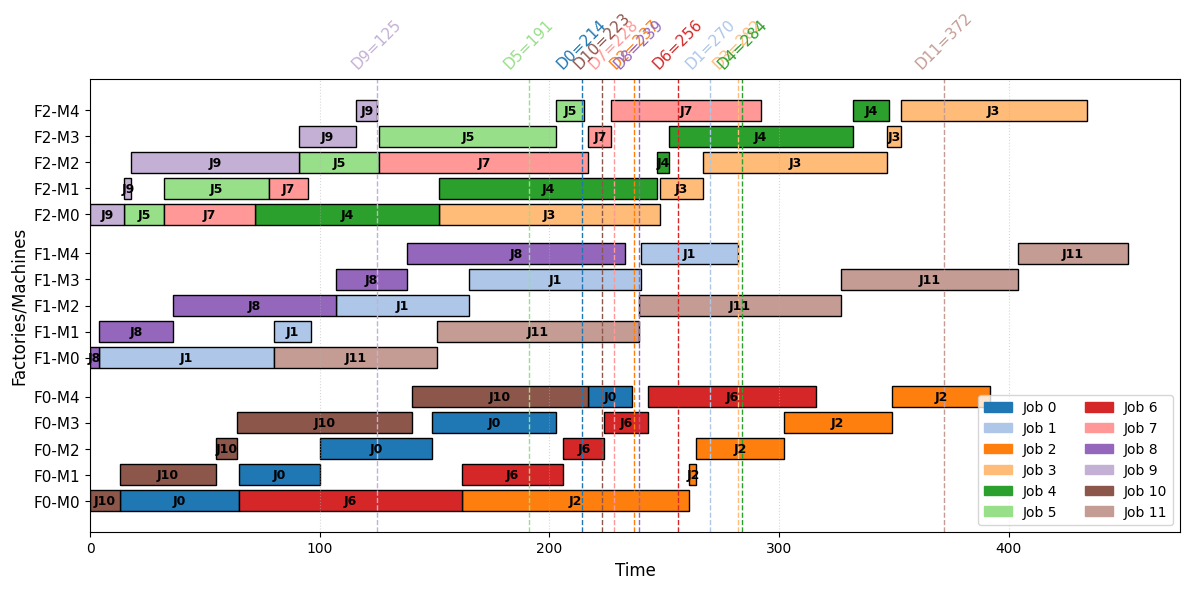

In [173]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Collect all the keys from result
FACTORIES = sorted({f for (_, f, _) in result["start_times"].keys()})
MACHINES = sorted({m for (_, _, m) in result["start_times"].keys()})
JOBS = sorted(ptime.keys())

colors = plt.colormaps.get_cmap("tab20")
fig, ax = plt.subplots(figsize=(12, 6))
yticks, ylabels = [], []
bar_height = 0.8          # increased from 0.35
label_fontsize = 9       # increased text size

for f in FACTORIES:
    for m in MACHINES:
        y = f * (len(MACHINES) + 0.5) + m
        yticks.append(y)
        ylabels.append(f"F{f}-M{m}")

        for (j, ff, mm), start in result["start_times"].items():
            if f == ff and m == mm and start is not None:
                dur = ptime[j][m]
                if dur is None or isinstance(dur, str):
                    continue

                ax.barh(
                    y,
                    dur,
                    left=start,
                    height=bar_height,
                    color=colors(j % len(JOBS)),
                    edgecolor="black",
                    align="center"
                )

                ax.text(
                    start + dur / 2,
                    y,
                    f"J{j}",
                    va="center",
                    ha="center",
                    fontsize=label_fontsize,
                    color="black",
                    fontweight="bold"
                )

# --- Due Dates ---
for j in JOBS:
    Dj = jobs_due_date[j]
    ax.axvline(Dj, color=colors(j % len(JOBS)), linestyle="--", linewidth=1)
    ax.text(
        Dj,
        max(yticks) + 1.5,
        f"D{j}={Dj}",
        rotation=45,
        va="bottom",
        ha="center",
        fontsize=11,
        color=colors(j % len(JOBS))
    )

ax.set_yticks(yticks)
ax.set_yticklabels(ylabels, fontsize=11)
ax.set_xlabel("Time", fontsize=12)
ax.set_ylabel("Factories/Machines", fontsize=12)
# ax.set_title(f"Gantt Chart (Total Tardiness = {result.get('objective', 0):.0f})", fontsize=14)

ax.grid(True, axis="x", linestyle=":", alpha=0.5)

# --- Legend ---
patches = [mpatches.Patch(color=colors(j % len(JOBS)), label=f"Job {j}") for j in JOBS]
ax.legend(handles=patches, loc="lower right", fontsize=10, ncol=2)

plt.tight_layout()
plt.show()

In [174]:
summary = {
    "Solver Status": result["status"],
    "Objective (Total Tardiness)": result["objective"],
    "Best Bound": result["best_bound"],
    "Optimality Gap (%)": round(100 * (result["objective"] - result["best_bound"]) / result["objective"], 2)
    }
       
jobs_df = pd.DataFrame([
    {
    "Job": j,
    "Due Date": jobs_due_date[j],
    "Finished": result["start_times"][j,result["assignment"][j],M-1] + ptime[j][M-1],
    "Tardiness": result["tardiness"][j],
    "Factory": result["assignment"][j],
    }
    for j in result["assignment"]
    ])

FACTORIES = sorted({f for (_, f, _) in result["start_times"].keys()})
       
print(pd.DataFrame([summary]))                              #print SUMMARY
print(jobs_df)                                              #print jobs Assignments

  Solver Status  Objective (Total Tardiness)  Best Bound  Optimality Gap (%)
0      FEASIBLE                        633.0       362.0               42.81
    Job  Due Date  Finished  Tardiness  Factory
0     0       214       236         22        0
1     1       270       282         12        1
2     2       237       392        155        0
3     3       282       434        152        2
4     4       284       348         64        2
5     5       191       215         24        2
6     6       256       316         60        0
7     7       228       292         64        2
8     8       239       233          0        1
9     9       125       125          0        2
10   10       223       217          0        0
11   11       372       452         80        1
